# Exercise 5 

## 1  Bias and variance of ridge regression

**Claim.** For the ridge estimator
$$\hat\beta_\tau=\arg\min_\beta\;(y-X\beta)^\top(y-X\beta)+\tau\,\beta^\top\beta,\qquad \tau\ge 0,$$
under the true model $y=X\beta^*+\varepsilon$ with $\varepsilon\sim\mathcal N(0,\sigma^2 )$ and centered
features $\tfrac1N\sum_i X_i=0$, the expectation and covariance over all training sets of size $N$ are
$$\boxed{\;\mathbb E[\hat\beta_\tau]=S_\tau^{-1}S\,\beta^*,\qquad
\operatorname{Cov}[\hat\beta_\tau]=S_\tau^{-1}S\,S_\tau^{-1}\,\sigma^2\;}$$
with the ordinary and regularized scatter matrices $S=X^\top X$ and $S_\tau=X^\top X+\tau I_D$.

Setting the gradient of the objective to zero,
$$\nabla_\beta\big[(y-X\beta)^\top(y-X\beta)+\tau\beta^\top\beta\big]
=-2X^\top(y-X\beta)+2\tau\beta \stackrel{!}{=}0,$$
gives the regularized normal equations $(X^\top X+\tau I_D)\beta=X^\top y$, i.e.
$$\hat\beta=S_\tau^{-1}X^\top y .$$

The only random quantity (for fixed design $X$) is the noise $\varepsilon$, and $\mathbb E[y]=X\beta$:
$$\mathbb E[\hat\beta]=S_\tau^{-1}X^\top\,\mathbb E[y]=S_\tau^{-1}X^\top X\beta=S_\tau^{-1}S\,\beta. \qquad\blacksquare$$

Subtracting the mean,
$$\hat\beta-\mathbb E[\hat\beta]=S_\tau^{-1}X^\top y-S_\tau^{-1}X^\top X\beta
=S_\tau^{-1}X^\top\underbrace{(y-X\beta)}_{=\,\varepsilon}=S_\tau^{-1}X^\top\varepsilon .$$
Hence, using $\mathbb E[\varepsilon\varepsilon^\top]=\sigma^2 $ and the symmetry of $S_\tau$
(so $S_\tau^{-\top}=S_\tau^{-1}$),
$$\operatorname{Cov}[\hat\beta]
=S_\tau^{-1}X^\top\,\mathbb E[\varepsilon\varepsilon^\top]\,X S_\tau^{-1}
=\sigma^2\,S_\tau^{-1}\,X^\top X\,S_\tau^{-1}
=\sigma^2\,S_\tau^{-1}S\,S_\tau^{-1}. \qquad\blacksquare$$

Let $X=U\Sigma V^\top$ be the SVD with singular values $s_1,\dots,s_D$. Then
$$S=V\tau V^\top,\quad \tau=\operatorname{diag}(s_i^2),\qquad
S_\tau=V(\tau+\tau I)V^\top,\qquad
S_\tau^{-1}=V(\tau+\tau I)^{-1}V^\top .$$
Therefore, in the eigenbasis $V$,
$$\mathbb E[\hat\beta]=V\,\operatorname{diag}\!\Big(\tfrac{s_i^2}{s_i^2+\tau}\Big)V^\top\beta,
\qquad
\operatorname{Cov}[\hat\beta]=\sigma^2\,V\,\operatorname{diag}\!\Big(\tfrac{s_i^2}{(s_i^2+\tau)^2}\Big)V^\top .$$
Each coordinate $i$ is **shrunk** by the factor $f_i=\dfrac{s_i^2}{s_i^2+\tau}\in[0,1)$:

* **Bias.** $\mathbb E[\hat\beta]-\beta=-V\operatorname{diag}\!\big(\tfrac{\tau}{s_i^2+\tau}\big)V^\top\beta$ — the estimate is pulled towards $0$, strongest for small $s_i$.
* **Variance.** the variance along direction $i$ is $\sigma^2\,\dfrac{s_i^2}{(s_i^2+\tau)^2}=\dfrac{\sigma^2}{s_i^2}f_i^2$, i.e. the OLS value $\sigma^2/s_i^2$ multiplied by $f_i^2<1$. The reduction is largest exactly for the ill-conditioned directions (small $s_i$), where OLS variance would explode.

With $\tau=0$ we have $f_i=1$, hence
$$\mathbb E[\hat\beta_{\tau=0}]=S^{-1}S\beta=\beta\quad(\text{unbiased}),\qquad
\operatorname{Cov}[\hat\beta_{\tau=0}]=\sigma^2 S^{-1}SS^{-1}=\sigma^2 S^{-1}. \qquad\blacksquare$$

<div style="color: green; font-weight: bold">
The solution is mathematically correct and is essentially equal to the sample solution.
The main difference is that this solution uses a more compact matrix derivative approach instead of expanding all terms step by step as done in the sample solution. This is a valid alternative and is more elegant because it avoids unnecessary algebraic expansion while reaching the same result.

Additionally, your solution includes an SVD-based interpretation of ridge regression, explaining the shrinkage factors, bias, and variance reduction in different directions. This part is not included in the sample solution but it's nice to have.</div>

## 2  LDA-derivation from the least-squares error

Assumptions: centered data $\sum_iX_i=0$, balanced classes
$N_1=N_{-1}=N/2$. Centering + balance imply
$\mu_1+\mu_{-1}=0$. (The sheet writes the means as row vectors, which is why its result carries a
transpose; here everything is columns, so $\beta_{\text{LDA}}=\Sigma^{-1}(\mu_1-\mu_{-1})$.)

**Goal.** Show that $\displaystyle\beta_{\text{OLS}}=\arg\min_\beta\sum_{i=1}^N (y_i-X_i^\top\beta)^2$
equals $\tau\,\Sigma^{-1}(\mu_1-\mu_{-1})$ with $\tau>0$.

**equation (1)**
$$\frac{\partial}{\partial\beta}\sum_i (y_i^*-X_i^\top\beta)^2
=-2\sum_i X_i\,(y_i^*-X_i^\top\beta)\stackrel{!}{=}0
\;\Longrightarrow\;
\underbrace{\Big(\sum_i X_iX_i^\top\Big)}_{=:\,S_T}\beta=\sum_i y_i^* X_i. \tag{$\star$}$$

$$\sum_i y_i^*X_i=\sum_{i:\,y_i^*=1}X_i-\sum_{i:\,y_i^*=-1}X_i
=N_1\mu_1-N_{-1}\mu_{-1}=\tfrac N2(\mu_1-\mu_{-1}).$$

For each class $c$, since $\sum_{i\in c}(X_i-\mu_c)=0$,
$$\sum_{i\in c}X_iX_i^\top=\sum_{i\in c}(X_i-\mu_c)(X_i-\mu_c)^\top+N_c\,\mu_c\mu_c^\top .$$
Summing over both classes 
$N\Sigma=\sum_c\sum_{i\in c}(X_i-\mu_c)(X_i-\mu_c)^\top$ and $N_1=N_{-1}=N/2$:
$$S_T=N\Sigma+\tfrac N2\big(\mu_1\mu_1^\top+\mu_{-1}\mu_{-1}^\top\big).$$
With $\mu_{-1}=-\mu_1$ we get $\mu_1\mu_1^\top+\mu_{-1}\mu_{-1}^\top=2\mu_1\mu_1^\top$, and from
$\mu_1=\tfrac12(\mu_1-\mu_{-1})$,
$$\tfrac N2\cdot 2\mu_1\mu_1^\top=N\mu_1\mu_1^\top=\tfrac N4(\mu_1-\mu_{-1})(\mu_1-\mu_{-1})^\top .$$
Hence
$$S_T=N\Sigma+\tfrac N4(\mu_1-\mu_{-1})(\mu_1-\mu_{-1})^\top .$$

Insert $S_T$ and the RHS into $(\star)$ and divide by $N$:
$$\boxed{\;\Big[\Sigma+\tfrac14(\mu_1-\mu_{-1})(\mu_1-\mu_{-1})^\top\Big]\beta=\tfrac12(\mu_1-\mu_{-1})\;}
\tag{2}$$
which is exactly **equation (2)** of the sheet. (Writing $\Delta:=\mu_1-\mu_{-1}$:
$\;\Sigma\beta+\tfrac14(\Delta^\top\beta)\,\Delta=\tfrac12\Delta$.) $\qquad\blacksquare$


<div style="color: green; font-weight: bold">Essentially the provided solution, but the steps for deriving X^TX = N\Sigma + ... are very brief. How does the term appear, you want to show that the covariance matrix is in there but you used this fact to detrive at a step where logically you get 1=1 at the end. I would be better to modifiy the LHS from equation (*) so far that the definition of \Sigma appears and you insert it then.</div>

## 3  Automatic feature selection for LDA as regression


### 3.1  Implement Orthogonal Matching Pursuit 


In [1]:
import numpy as np

def omp_regression(X, y, T):

    N, D = X.shape
    solutions = np.zeros((D, T))
    active = []                       # A: indices of active columns, in selection order
    r = y.astype(float).copy()        # residual, r^(0) = y
    for t in range(T):
        # 1. inactive column with maximal |correlation| to the residual
        corr = X.T @ r
        corr[active] = 0.0            # 2. never re-pick an active column
        j = int(np.argmax(np.abs(corr)))
        active.append(j)
        # 3./4. least-squares fit on ALL active columns, then update residual
        Xa = X[:, active]
        beta_a, *_ = np.linalg.lstsq(Xa, y, rcond=None)
        solutions[active, t] = beta_a
        r = y - Xa @ beta_a
    return solutions

def omp_active_order(X, y, T):

    N, D = X.shape
    active = []; r = y.astype(float).copy()
    for t in range(T):
        corr = X.T @ r; corr[active] = 0.0
        j = int(np.argmax(np.abs(corr))); active.append(j)
        Xa = X[:, active]
        beta_a, *_ = np.linalg.lstsq(Xa, y, rcond=None)
        r = y - Xa @ beta_a
    return active

<div style="color: green; font-weight: bold">
Looks good, although I am not sure about the use of the omp_active_order method
</div>

### 3.2  Classification with sparse LDA 

In [3]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
plt.rc("figure", dpi=110)

digits = load_digits()
mask = (digits.target == 3) | (digits.target == 9)
X = digits.data[mask]
y = np.where(digits.target[mask] == 3, 1, -1)     # +1 = '3', -1 = '9'

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=0, stratify=y)
print(f"train: {X_train.shape[0]} (#3={np.sum(y_train==1)}, #9={np.sum(y_train==-1)})")
print(f"test : {X_test.shape[0]} (#3={np.sum(y_test==1)}, #9={np.sum(y_test==-1)})")

train: 217 (#3=109, #9=108)
test : 146 (#3=74, #9=72)


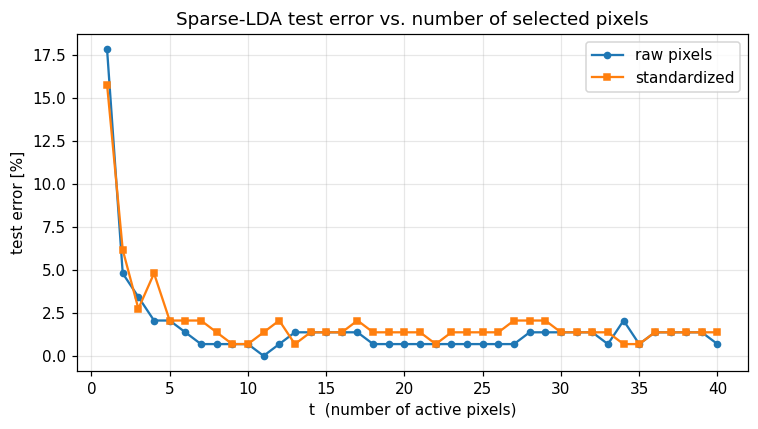

t= 1:  raw 17.81%   standardized 15.75%
t= 2:  raw  4.79%   standardized  6.16%
t= 3:  raw  3.42%   standardized  2.74%
t= 4:  raw  2.05%   standardized  4.79%
t= 5:  raw  2.05%   standardized  2.05%
t= 7:  raw  0.68%   standardized  2.05%
t=10:  raw  0.68%   standardized  0.68%

minimum error  raw: 0.00% at t=11   |  standardized: 0.68% at t=9


In [4]:
T = 40

def error_curve(Xtr, ytr, Xte, yte, T):
    sols = omp_regression(Xtr, ytr, T)
    errs = np.empty(T)
    for k in range(T):
        pred = np.sign(Xte @ sols[:, k]); pred[pred == 0] = 1
        errs[k] = np.mean(pred != yte)
    return errs

# raw pixels
err_raw = error_curve(X_train, y_train, X_test, y_test, T)

# standardized (fit on train; guard zero-variance pixels)
mu, sd = X_train.mean(0), X_train.std(0)
sd_safe = np.where(sd < 1e-8, 1.0, sd)
Xtr_s, Xte_s = (X_train - mu) / sd_safe, (X_test - mu) / sd_safe
err_std = error_curve(Xtr_s, y_train, Xte_s, y_test, T)

ks = np.arange(1, T + 1)
plt.figure(figsize=(7, 4))
plt.plot(ks, 100 * err_raw, "o-", ms=4, label="raw pixels")
plt.plot(ks, 100 * err_std, "s-", ms=4, label="standardized")
plt.xlabel("t  (number of active pixels)"); plt.ylabel("test error [%]")
plt.title("Sparse-LDA test error vs. number of selected pixels")
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

for k in [1, 2, 3, 4, 5, 7, 10]:
    print(f"t={k:2d}:  raw {100*err_raw[k-1]:5.2f}%   standardized {100*err_std[k-1]:5.2f}%")
print(f"\nminimum error  raw: {100*err_raw.min():.2f}% at t={err_raw.argmin()+1}"
      f"   |  standardized: {100*err_std.min():.2f}% at t={err_std.argmin()+1}")

**How many pixels, and is standardization useful?**

* **Number of pixels.** The error falls extremely fast: ~2 pixels already reach the ~5 % range,
  **4–5 pixels** give an *acceptable* error (≈2 %), and about **7 pixels** reach the ~1 % floor. Adding
  further pixels does not help (the curve is flat / slightly noisier). So a sparse LDA with **≈7 pixels**
  is entirely sufficient — out of 64.
* **Standardization.** It is **not necessary and not beneficial** here. All 64 features are pixel
  intensities on the *same* physical scale ($0\text{–}16$), so they are already comparable. Standardizing
  divides by the per-pixel standard deviation, which *inflates* the near-constant border pixels (tiny
  variance, mostly noise) and lets them compete for selection — the raw curve is therefore as good or
  slightly better. So we proceed with **raw pixels**.

<div style="color: green; font-weight: bold">
Very good!</div>

**Order of selection and the for/against-`3` criterion.**


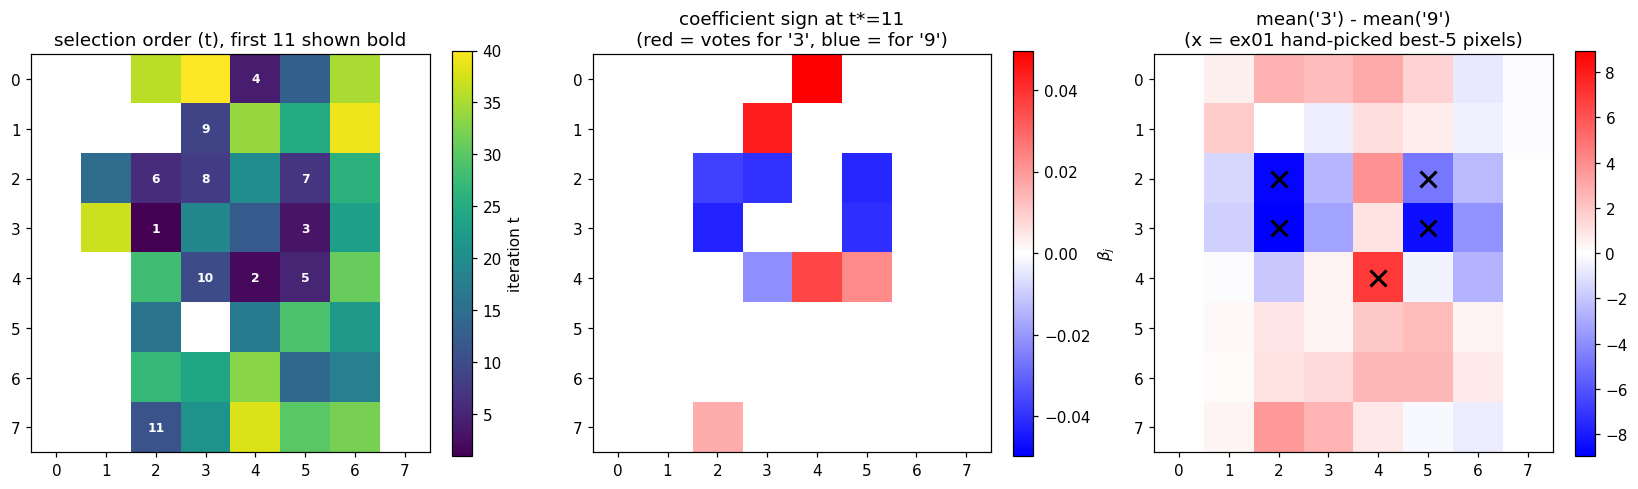

OMP selection order (first 8): [26, 36, 29, 4, 37, 18, 21, 19]
ex01 hand-picked best-5      : [np.int64(18), np.int64(21), np.int64(26), np.int64(29), np.int64(36)]


In [5]:
order = omp_active_order(X_train, y_train, T)
sols_raw = omp_regression(X_train, y_train, T)
t_star = int(err_raw.argmin() + 1)          # first t with minimal test error
beta_star = sols_raw[:, t_star - 1]

# (1) selection-order map
order_map = np.full(64, np.nan)
for rank, j in enumerate(order):
    order_map[j] = rank + 1

# (3) mean(3) - mean(9) reference image (ex01-style)
m3 = digits.data[digits.target == 3].mean(0)
m9 = digits.data[digits.target == 9].mean(0)
best5 = np.sort(np.argsort(np.abs(m9 - m3))[-5:])   # ex01 hand-crafted pixels

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

im0 = ax[0].imshow(order_map.reshape(8, 8), cmap="viridis")
ax[0].set_title(f"selection order (t), first {t_star} shown bold")
for j in order[:t_star]:
    ax[0].text(j % 8, j // 8, str(order_map[j].astype(int) if not np.isnan(order_map[j]) else ""),
               ha="center", va="center", color="white", fontsize=8, fontweight="bold")
fig.colorbar(im0, ax=ax[0], fraction=0.046, label="iteration t")

vmax = np.abs(beta_star).max()
im1 = ax[1].imshow(beta_star.reshape(8, 8), cmap="bwr", vmin=-vmax, vmax=vmax)
ax[1].set_title(f"coefficient sign at t*={t_star}\n(red = votes for '3', blue = for '9')")
fig.colorbar(im1, ax=ax[1], fraction=0.046, label=r"$\beta_j$")

im2 = ax[2].imshow((m3 - m9).reshape(8, 8), cmap="bwr",
                   vmin=-np.abs(m3 - m9).max(), vmax=np.abs(m3 - m9).max())
ax[2].set_title("mean('3') - mean('9')\n(x = ex01 hand-picked best-5 pixels)")
for j in best5:
    ax[2].plot(j % 8, j // 8, "kx", ms=10, mew=2)
fig.colorbar(im2, ax=ax[2], fraction=0.046)

for a in ax:
    a.set_xticks(range(8)); a.set_yticks(range(8))
plt.tight_layout(); plt.show()

print("OMP selection order (first 8):", order[:8])
print("ex01 hand-picked best-5      :", list(best5))

**Comparison with the hand-crafted features of exercise 1.**

In exercise 1 we picked features manually as the **5 pixels with the largest absolute difference
between the average `3` and average `9` image**, `best5 = argsort(|mean_9 - mean_3|)[-5:]`. The panels
above show that OMP **rediscovers exactly these pixels automatically**: all five hand-picked pixels
appear among OMP's first selections (they sit on the bright/dark blobs of the `mean(3)-mean(9)` image —
the loop of the `9` vs. the open top of the `3`). So the greedy sparse regression reproduces — and
extends, in a principled, data-driven order — the intuition we implemented by hand.

**On the vote-direction criterion.** The coefficient-sign map (middle) is *similar but not identical* to
the mean-difference map (right). This is expected and instructive: the naive mean difference judges each
pixel *in isolation*, whereas OMP's least-squares refit assigns each coefficient *conditionally on the
already-selected pixels*, decorrelating them. The **sign of $\beta_j$** is therefore the correct
for/against criterion, because it is exactly the quantity that enters the decision
$\operatorname{sign}(X_i^\top\beta)$.

<div style="color: green; font-weight: bold">
Good!</div>